# Convolutional Undercomplete Autoencoder

- Reference: https://youtu.be/zp8clK9yCro

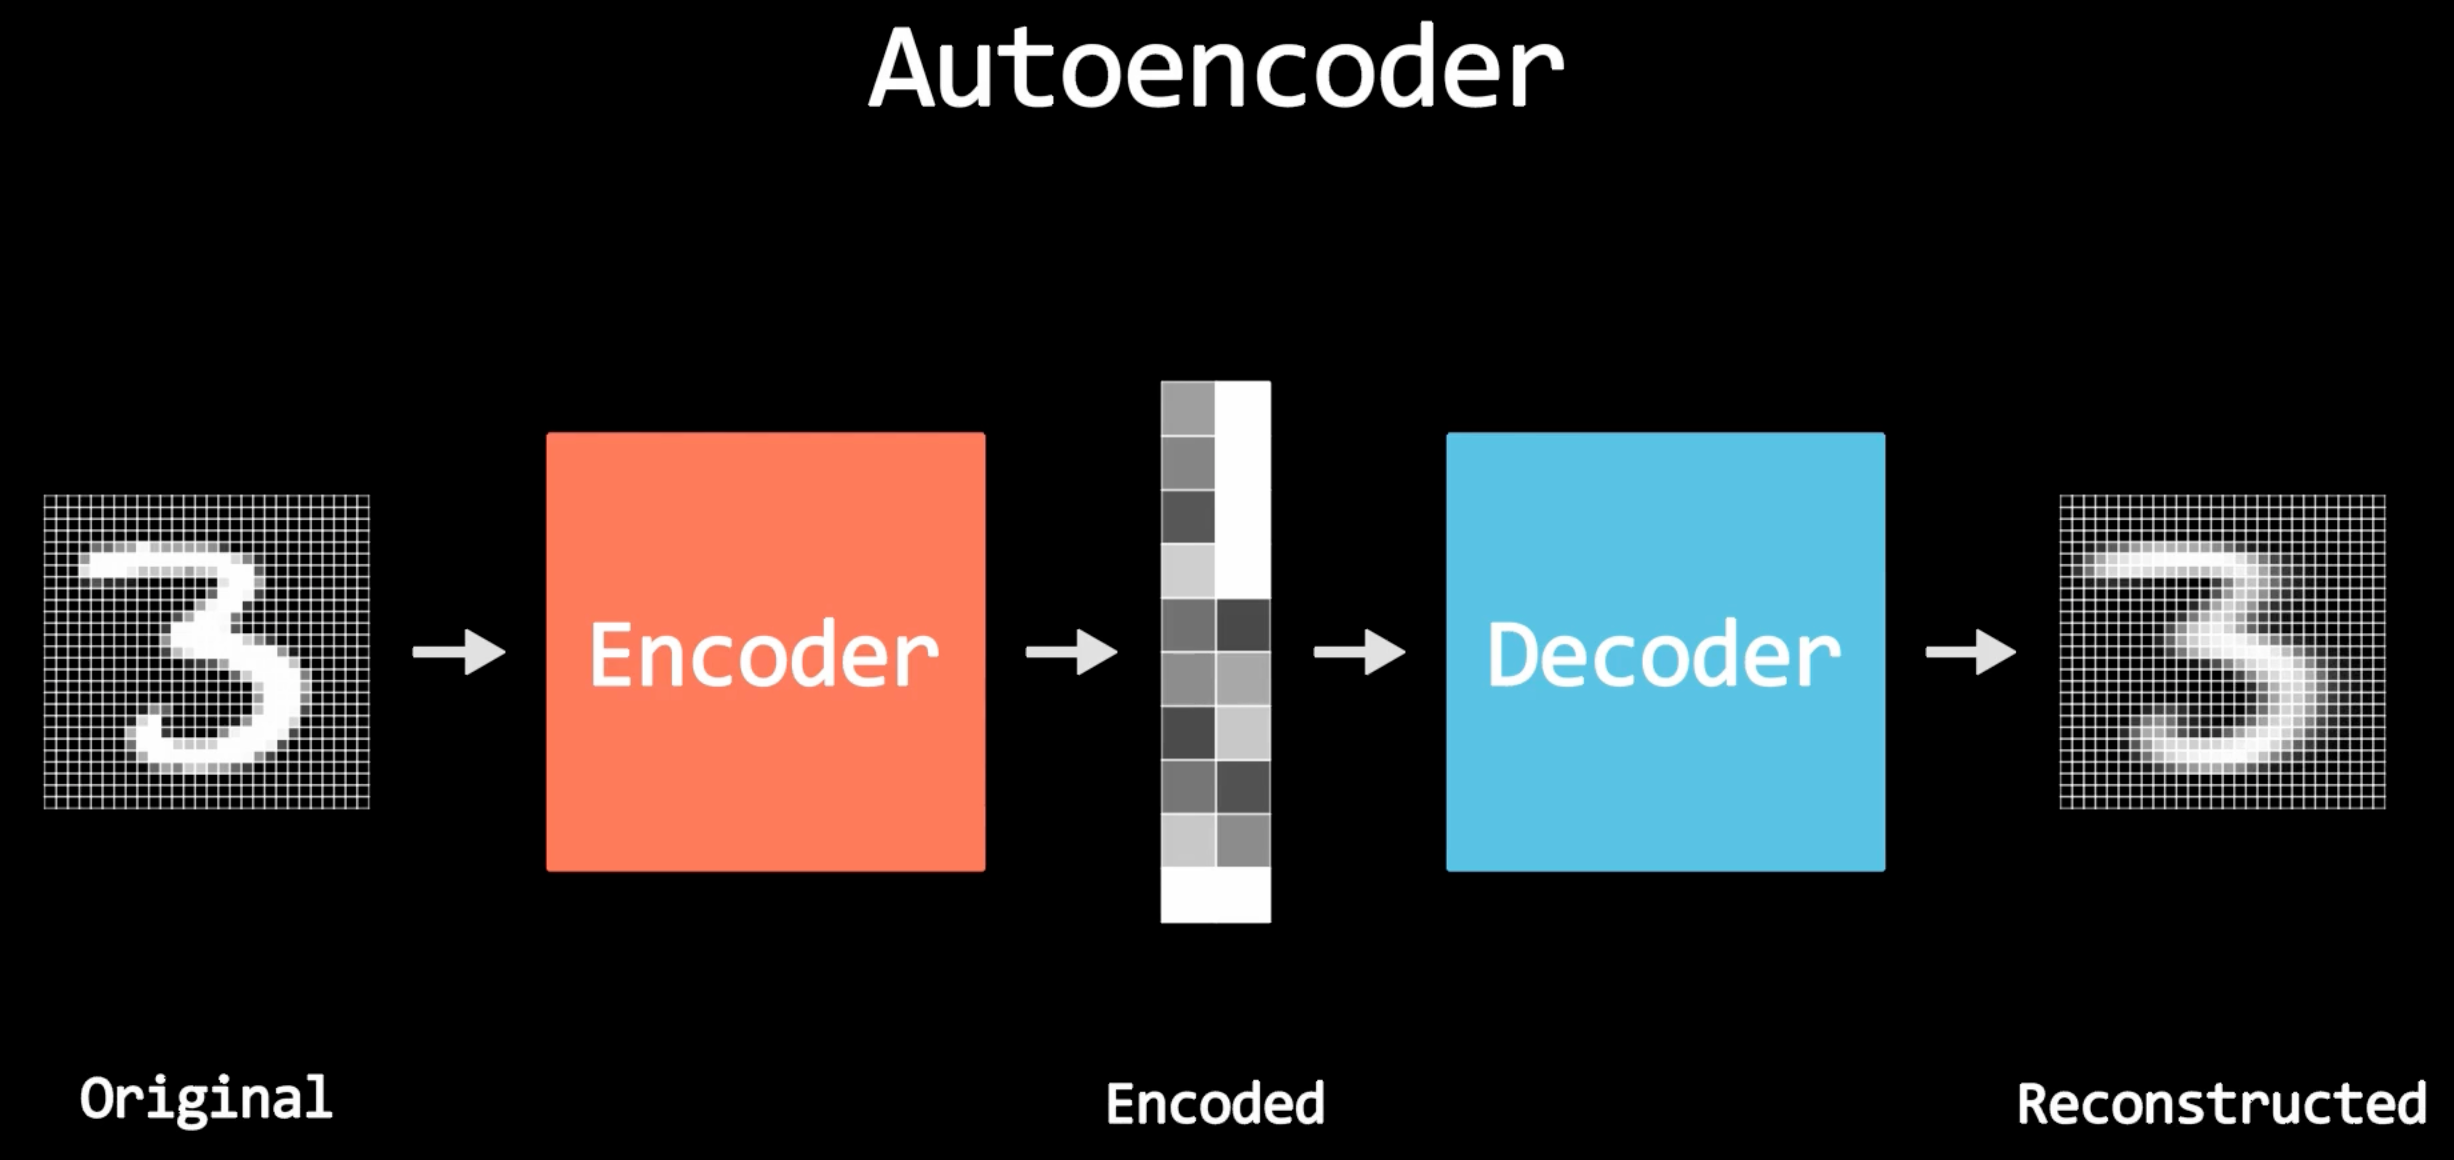


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()  # tensor(0.) tensor(1.)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5), (0.5))
# ])  # -> tensor(-1.) tensor(1.) for tanh activation function

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data,
                                          batch_size=64,
                                          shuffle=True)

In [3]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Reduce the size
        # N(=batch size), 784(=28x28)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)  # -> N, 3
        )

        self.decoder = nn.Sequential(
            # N, 3 -> N, 784

            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Activation Funciton
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        
        super().__init__()
        self.encoder = nn.Sequential(
            # N, 1, 28, 28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # N, 16, 14, 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7) # stride=1, padding=0 # N, 64, 1, 1
        )

        self.decoder = nn.Sequential(
            # N, 64, 1, 1
            nn.ConvTranspose2d(64, 32, 7), # N, 32, 7, 7
            nn.ReLU(),           
            # IMPORTNAT! use output_padding to produce output spatial size 14, not 13
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh
# nn.MaxPool2d <-> nn.MaxUnpool2d

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Using device: cuda
NVIDIA GeForce RTX 5080


In [7]:
num_epochs = 10
outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        # img = img.reshape(-1, 28 * 28) # for Autoencoder_Linear
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch:{epoch + 1}, Loss:{loss.item():.4f}')
    outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))  # original image, reconstructed image

Epoch:1, Loss:0.0084
Epoch:2, Loss:0.0052
Epoch:3, Loss:0.0040
Epoch:4, Loss:0.0040
Epoch:5, Loss:0.0033
Epoch:6, Loss:0.0029
Epoch:7, Loss:0.0028
Epoch:8, Loss:0.0029
Epoch:9, Loss:0.0027
Epoch:10, Loss:0.0029


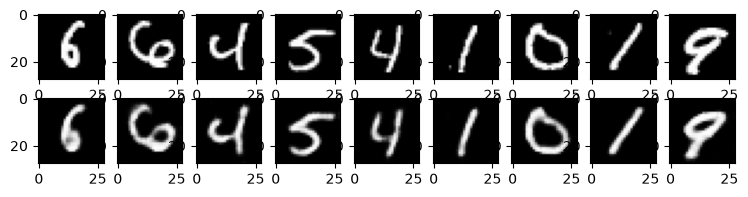

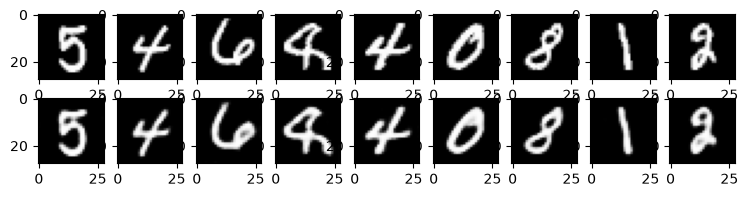

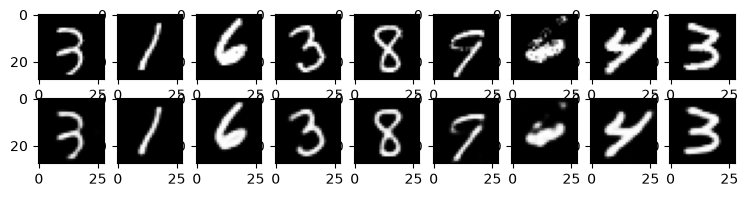

In [8]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2, 9, i + 1)
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9:
            break
        plt.subplot(2, 9, 9 + i + 1)  # row_length + i + 1
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])

## Latent space visualization

Visualize the 64-dimensional CNN autoencoder latent vectors with PCA and t-SNE.


In [9]:
model.eval()
model_device = next(model.parameters()).device

latent_batches = []
label_batches = []

with torch.no_grad():
    for imgs, labels in data_loader:
        imgs = imgs.to(model_device)
        z = model.encoder(imgs)                 # N, 64, 1, 1
        z = z.view(z.size(0), -1)               # N, 64
        latent_batches.append(z.cpu())
        label_batches.append(labels.cpu())

latents = torch.cat(latent_batches, dim=0)
latent_labels = torch.cat(label_batches, dim=0)

print(latents.shape)
print(latent_labels.shape)

torch.Size([60000, 64])
torch.Size([60000])


In [10]:
# Choose which labels to visualize here.
selected_digits = [0, 1]
num_vis = 5000
random_seed = 42

selected_digits_tensor = torch.tensor(selected_digits)
label_mask = torch.isin(latent_labels, selected_digits_tensor)
filtered_idx = torch.where(label_mask)[0]

num_vis = min(num_vis, filtered_idx.numel())
generator = torch.Generator().manual_seed(random_seed)
vis_idx = filtered_idx[torch.randperm(filtered_idx.numel(), generator=generator)[:num_vis]]

latents_vis = latents[vis_idx]
labels_vis = latent_labels[vis_idx]

print(f"selected digits: {selected_digits}")
print(latents_vis.shape)
print(torch.bincount(labels_vis, minlength=10))

selected digits: [0, 1]
torch.Size([5000, 64])
tensor([2356, 2644,    0,    0,    0,    0,    0,    0,    0,    0])


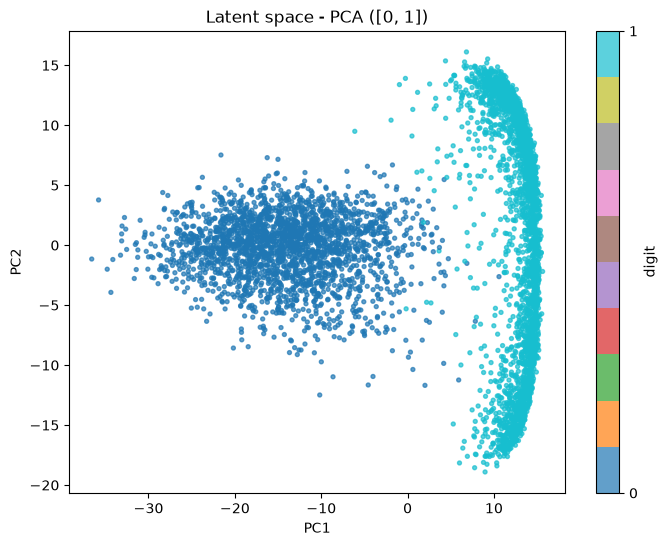

In [11]:
# Latent space visualization 1: PCA
latents_centered = latents_vis - latents_vis.mean(dim=0, keepdim=True)
_, _, v = torch.pca_lowrank(latents_centered, q=2)
latents_pca = latents_centered @ v[:, :2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_pca[:, 0].numpy(),
    latents_pca[:, 1].numpy(),
    c=labels_vis.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.7,
)
plt.colorbar(scatter, ticks=selected_digits, label="digit")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Latent space - PCA ({selected_digits})")
plt.show()

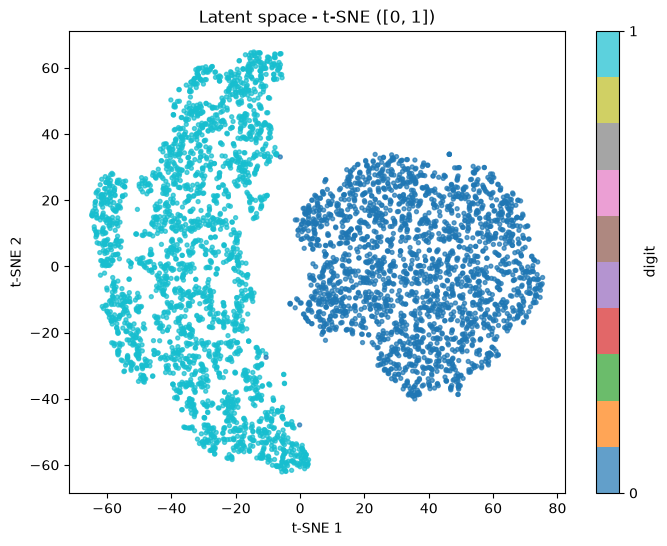

In [12]:
# Latent space visualization 2: t-SNE
from sklearn.manifold import TSNE

latents_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=random_seed,
).fit_transform(latents_vis.numpy())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents_tsne[:, 0],
    latents_tsne[:, 1],
    c=labels_vis.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.7,
)
plt.colorbar(scatter, ticks=selected_digits, label="digit")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"Latent space - t-SNE ({selected_digits})")
plt.show()

## 1-D Manifold: Vertical Translation

Fix one MNIST image and move it only up and down. The vertical shift is the single degree of freedom, so these images form a 1-D manifold in the original 784-D image space.

PCA is used only to project that path to 2-D for visualization. The second plot encodes the same translated images and shows their path in the autoencoder's 64-D latent space.


In [13]:
# Change these values to try another digit or translation range.
manifold_digit = 9
vertical_shifts = list(range(-8, 9))


def translate_vertical(img, shift):
    """Translate a CHW image vertically and fill the empty area with zeros."""
    translated = torch.zeros_like(img)
    if shift > 0:  # move down
        translated[:, shift:, :] = img[:, :-shift, :]
    elif shift < 0:  # move up
        translated[:, :shift, :] = img[:, -shift:, :]
    else:
        translated.copy_(img)
    return translated


base_img = next(img for img, label in mnist_data if label == manifold_digit)
translated_imgs = torch.stack(
    [translate_vertical(base_img, shift) for shift in vertical_shifts]
)

print("translated images:", translated_imgs.shape)
print("one degree of freedom: vertical shift")


translated images: torch.Size([17, 1, 28, 28])
one degree of freedom: vertical shift


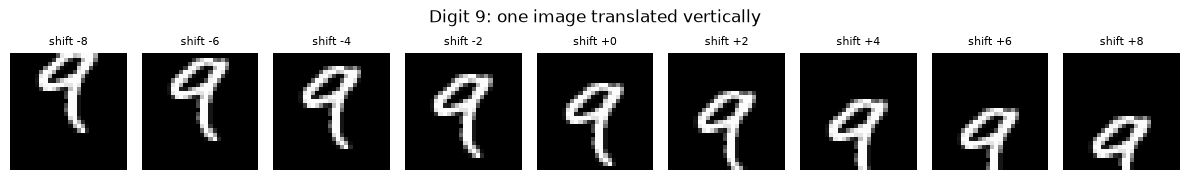

In [14]:
# The generated points of the 1-D manifold.
show_indices = list(range(0, len(vertical_shifts), 2))

plt.figure(figsize=(12, 1.8))
plt.gray()
for plot_idx, image_idx in enumerate(show_indices):
    ax = plt.subplot(1, len(show_indices), plot_idx + 1)
    ax.imshow(translated_imgs[image_idx].squeeze().numpy())
    ax.set_title(f"shift {vertical_shifts[image_idx]:+d}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Digit {manifold_digit}: one image translated vertically")
plt.tight_layout()
plt.show()


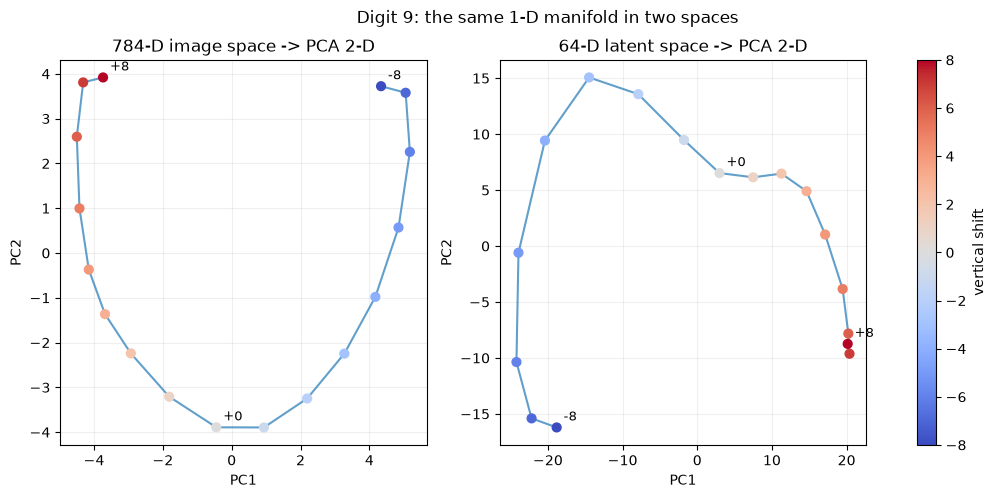

In [15]:
# Left: PCA of the 784-D pixel vectors.
# Right: PCA of the same path after the encoder maps it to 64-D latent vectors.
pixel_vectors = translated_imgs.view(len(translated_imgs), -1)
pixel_centered = pixel_vectors - pixel_vectors.mean(dim=0, keepdim=True)
_, _, pixel_components = torch.pca_lowrank(pixel_centered, q=2)
pixel_path_2d = pixel_centered @ pixel_components[:, :2]

model.eval()
with torch.no_grad():
    latent_vectors = model.encoder(translated_imgs.to(device)).flatten(start_dim=1).cpu()

latent_centered = latent_vectors - latent_vectors.mean(dim=0, keepdim=True)
_, _, latent_components = torch.pca_lowrank(latent_centered, q=2)
latent_path_2d = latent_centered @ latent_components[:, :2]

shift_colors = torch.tensor(vertical_shifts)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, points, title in [
    (axes[0], pixel_path_2d, "784-D image space -> PCA 2-D"),
    (axes[1], latent_path_2d, "64-D latent space -> PCA 2-D"),
]:
    ax.plot(points[:, 0].numpy(), points[:, 1].numpy(), color="tab:blue", alpha=0.7)
    scatter = ax.scatter(
        points[:, 0].numpy(),
        points[:, 1].numpy(),
        c=shift_colors.numpy(),
        cmap="coolwarm",
        s=40,
        zorder=3,
    )
    for idx in [0, len(vertical_shifts) // 2, len(vertical_shifts) - 1]:
        ax.annotate(
            f"{vertical_shifts[idx]:+d}",
            (points[idx, 0].item(), points[idx, 1].item()),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.grid(alpha=0.2)

fig.colorbar(scatter, ax=axes, label="vertical shift")
fig.suptitle(f"Digit {manifold_digit}: the same 1-D manifold in two spaces")
plt.show()


**Interpretation:** The learned latent space shows a continuous structure under vertical translation, indicating that the encoder preserves vertical translation information in the latent representation.


### How to Interpret the Result

- Each point is the same image at a different vertical shift. The color shows the shift value.
- A connected, smoothly ordered path means nearby vertical shifts remain nearby after projection. This is the expected 1-D manifold structure.
- The left plot shows the path in the original pixel representation. The right plot shows what remains after the encoder compresses it to 64 dimensions.
- If the latent path is smooth and ordered, the encoder preserves vertical translation continuously. Folding, jumps, or overlapping distant colors mean that this variation is distorted or discarded.
- PC1 and PC2 have no fixed semantic meaning here. Their direction and sign can flip between runs; the continuity and ordering of the path matter more than its orientation.


### Tangent Direction

At shift 0, the finite difference between the neighboring points approximates the tangent direction. Bright pixels increase and dark pixels decrease when moving downward along the manifold.


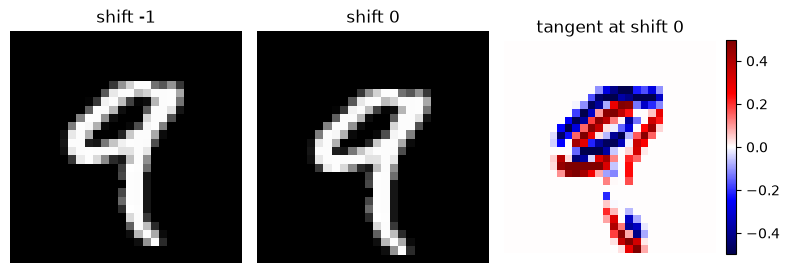

In [16]:
center_idx = vertical_shifts.index(0)
pixel_tangent = (
    translated_imgs[center_idx + 1] - translated_imgs[center_idx - 1]
) / 2

fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
axes[0].imshow(translated_imgs[center_idx - 1].squeeze().numpy(), cmap="gray")
axes[0].set_title("shift -1")
axes[1].imshow(translated_imgs[center_idx].squeeze().numpy(), cmap="gray")
axes[1].set_title("shift 0")
tangent_plot = axes[2].imshow(pixel_tangent.squeeze().numpy(), cmap="seismic")
axes[2].set_title("tangent at shift 0")

for ax in axes:
    ax.axis("off")

fig.colorbar(tangent_plot, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
